# TP — CPU vs GPU avec PyTorch

Objectif : comparer les performances CPU et GPU.

## 1. Vérification GPU

In [ ]:
import torch
print('CUDA disponible :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU :', torch.cuda.get_device_name(0))

CUDA disponible : True
GPU : Tesla T4


## 2. Fonction benchmark

In [ ]:
import time
def benchmark(device, size):
    A = torch.randn(size, size, device=device)
    B = torch.randn(size, size, device=device)
    if device == 'cuda': torch.cuda.synchronize()
    start = time.time()
    C = torch.matmul(A, B)
    if device == 'cuda': torch.cuda.synchronize()
    return time.time() - start

## 3. Test CPU

In [ ]:
size = 2000
cpu_time = benchmark('cpu', size)
print('Temps CPU:', cpu_time)

Temps CPU: 0.1711728572845459


## 4. Test GPU

In [ ]:
if torch.cuda.is_available():
    gpu_time = benchmark('cuda', size)
    print('Temps GPU:', gpu_time)
else:
    print('GPU non disponible')

Temps GPU: 0.11642026901245117


## 5. Comparaison

In [ ]:
if torch.cuda.is_available():
    print('Speedup x', cpu_time / gpu_time)

Speedup x 1.4703011660816463


## 6. Expérimentation

In [ ]:
for size in [500, 1000, 2000, 4000]:
    cpu = benchmark('cpu', size)
    if torch.cuda.is_available():
        gpu = benchmark('cuda', size)
        print(size, 'CPU:', cpu, 'GPU:', gpu, 'x', cpu/gpu)
    else:
        print(size, 'CPU:', cpu)

500 CPU: 0.00456547737121582 GPU: 0.00045680999755859375 x 9.994258872651358
1000 CPU: 0.02529287338256836 GPU: 0.0009324550628662109 x 27.12503196113526
2000 CPU: 0.20162487030029297 GPU: 0.006016969680786133 x 33.50937116139002
4000 CPU: 0.9782049655914307 GPU: 0.04571938514709473 x 21.395846913606


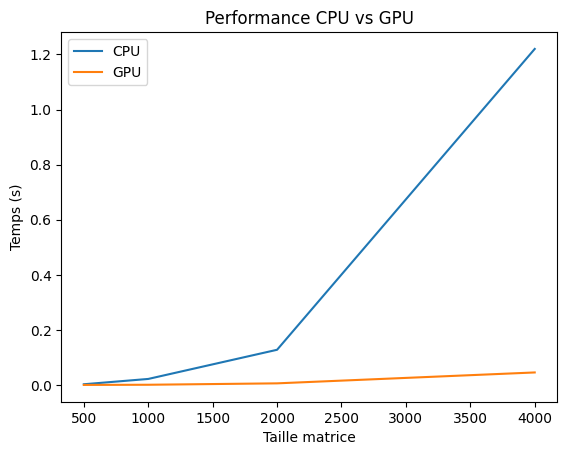

In [ ]:
import matplotlib.pyplot as plt

sizes = [500, 1000, 2000, 4000]
cpu_times = []
gpu_times = []

for size in sizes:
    cpu_times.append(benchmark("cpu", size))

    if torch.cuda.is_available():
        gpu_times.append(benchmark("cuda", size))
    else:
        gpu_times.append(None)

plt.plot(sizes, cpu_times, label="CPU")
plt.plot(sizes, gpu_times, label="GPU")
plt.xlabel("Taille matrice")
plt.ylabel("Temps (s)")
plt.title("Performance CPU vs GPU")
plt.legend()
plt.show()